In [3]:
#导入包
import fitparse
import gpxpy

# 相对路径
fit_path = './test_data/2026-06-09_摄氧量3030s41.fit'
gpx_path = './test_data/activity_23182812295.gpx'

# 读取 FIT 文件
fit_file = fitparse.FitFile(fit_path)

# 读取 GPX 文件
with open(gpx_path, 'r', encoding='utf-8') as f:
    gpx = gpxpy.parse(f)

print("FIT 文件读取成功")
print("GPX 文件读取成功")

FIT 文件读取成功
GPX 文件读取成功


In [4]:
fit_path = './test_data/2026-06-09_摄氧量3030s41.fit'
fit_file = fitparse.FitFile(fit_path)

# 查看所有消息类型
message_types = set()
for message in fit_file.get_messages():
    message_types.add(message.name)

print("FIT 文件中包含的消息类型:")
for msg_type in sorted(message_types):
    print(f"- {msg_type}")

FIT 文件中包含的消息类型:
- file_creator
- file_id
- workout
- workout_step


In [5]:
import fitparse

fit_path = './test_data/2026-06-09_摄氧量3030s41.fit'
fit_file = fitparse.FitFile(fit_path)

# 解析 workout 和 workout_step 消息
workouts = []
workout_steps = []

for message in fit_file.get_messages():
    if message.name == 'workout':
        workout_data = {}
        for field in message.fields:
            workout_data[field.name] = field.value
        workouts.append(workout_data)

    elif message.name == 'workout_step':
        step_data = {}
        for field in message.fields:
            step_data[field.name] = field.value
        workout_steps.append(step_data)

print("=== Workout (训练计划) ===")
for i, workout in enumerate(workouts):
    print(f"\n训练计划 {i+1}:")
    for key, value in workout.items():
        print(f"  {key}: {value}")

print("\n=== Workout Steps (训练步骤) ===")
for i, step in enumerate(workout_steps):
    print(f"\n步骤 {i+1}:")
    for key, value in step.items():
        print(f"  {key}: {value}")

=== Workout (训练计划) ===

训练计划 1:
  sport: cycling
  wkt_name: 摄氧量30/30s 4*15*30s
  num_valid_steps: 24

=== Workout Steps (训练步骤) ===

步骤 1:
  wkt_step_name: None
  duration_time: 180.0
  target_type: power
  target_power_zone: 0
  custom_target_power_low: 1126
  custom_target_power_high: 1150
  intensity: active
  unknown_19: None
  unknown_20: None
  unknown_21: None
  unknown_22: None
  message_index: 0
  duration_type: time

步骤 2:
  wkt_step_name: None
  duration_time: 180.0
  target_type: power
  target_power_zone: 0
  custom_target_power_low: 1145
  custom_target_power_high: 1168
  intensity: active
  unknown_19: None
  unknown_20: None
  unknown_21: None
  unknown_22: None
  message_index: 1
  duration_type: time

步骤 3:
  wkt_step_name: None
  duration_time: 180.0
  target_type: power
  target_power_zone: 0
  custom_target_power_low: 1161
  custom_target_power_high: 1184
  intensity: active
  unknown_19: None
  unknown_20: None
  unknown_21: None
  unknown_22: None
  message_index

In [6]:
import fitparse
import pandas as pd

fit_path = './test_data/2026-06-09_摄氧量3030s41.fit'
fit_file = fitparse.FitFile(fit_path)

workout_steps = []
for message in fit_file.get_messages('workout_step'):
    step = {}
    for field in message.fields:
        # 保留所有非 None 且有名字的字段
        if field.value is not None and not field.name.startswith('unknown'):
            step[field.name] = field.value
    workout_steps.append(step)

# 转为 DataFrame，自动包含所有字段
df = pd.DataFrame(workout_steps)
   
# 查看所有列名
print("所有列：", df.columns.tolist())
print(df)

所有列： ['duration_time', 'target_type', 'target_power_zone', 'custom_target_power_low', 'custom_target_power_high', 'intensity', 'message_index', 'duration_type', 'wkt_step_name', 'duration_step', 'repeat_steps']
    duration_time target_type  target_power_zone  custom_target_power_low  \
0           180.0       power                0.0                   1126.0   
1           180.0       power                0.0                   1145.0   
2           180.0       power                0.0                   1161.0   
3           180.0       power                0.0                   1179.0   
4           180.0       power                0.0                   1196.0   
5           240.0       power                0.0                   1115.0   
6            30.0       power                0.0                   1288.0   
7            30.0       power                0.0                   1115.0   
8             NaN         NaN                NaN                      NaN   
9           480.0  

In [9]:
import gpxpy

gpx_path = './test_data/activity_23182812295.gpx'

with open(gpx_path, 'r', encoding='utf-8') as f:
    gpx = gpxpy.parse(f)

print("GPX 文件读取成功")

# 遍历所有轨迹
for track in gpx.tracks:
    print(f"轨迹名称: {track.name}")

GPX 文件读取成功
轨迹名称: 摄氧量30/30s 4*15*30s


In [14]:
import gpxpy
from gpxpy.gpx import GPX, GPXTrack, GPXRoute, GPXWaypoint

# 读取 GPX 文件
gpx_path = './test_data/activity_23182812295.gpx'
with open(gpx_path, 'r', encoding='utf-8') as f:
    gpx = gpxpy.parse(f)

# 查看所有可用属性和方法
print("=== GPX 对象属性 ===")
print(f"版本: {gpx.version}")
print(f"创建者: {gpx.creator}")
print(f"\n所有属性: {[attr for attr in dir(gpx) if not attr.startswith('_')]}")

# 检查是否有扩展数据
print("\n=== 检查扩展数据 ===")
if hasattr(gpx, 'extensions') and gpx.extensions:
    print(f"扩展数据: {gpx.extensions}")

# 查看轨迹结构
print("\n=== 轨迹结构 ===")
print(f"轨迹数量: {len(gpx.tracks)}")
for i, track in enumerate(gpx.tracks):
    print(f"\n轨迹 {i+1}:")
    print(f"  名称: {track.name}")
    print(f"  描述: {track.description}")
    print(f"  分段数量: {len(track.segments)}")
    print(f"  属性: {[attr for attr in dir(track) if not attr.startswith('_')][:20]}")

    for j, segment in enumerate(track.segments):
        print(f"\n    分段 {j+1}:")
        print(f"      点数量: {len(segment.points)}")
        if segment.points:
            point = segment.points[0]
            print(f"      点属性: {[attr for attr in dir(point) if not attr.startswith('_')][:20]}")


=== GPX 对象属性 ===
版本: 1.1
创建者: Garmin Connect

所有属性: ['add_elevation', 'add_missing_data', 'add_missing_elevations', 'add_missing_speeds', 'add_missing_times', 'adjust_time', 'author_email', 'author_link', 'author_link_text', 'author_link_type', 'author_name', 'bounds', 'clone', 'copyright_author', 'copyright_license', 'copyright_year', 'creator', 'description', 'extensions', 'fill_time_data_with_regular_intervals', 'get_bounds', 'get_duration', 'get_elevation_extremes', 'get_location_at', 'get_moving_data', 'get_nearest_location', 'get_nearest_locations', 'get_points_data', 'get_points_no', 'get_time_bounds', 'get_track_points_no', 'get_uphill_downhill', 'gpx_10_fields', 'gpx_11_fields', 'has_elevations', 'has_times', 'keywords', 'length_2d', 'length_3d', 'link', 'link_text', 'link_type', 'metadata_extensions', 'move', 'name', 'nsmap', 'reduce_points', 'refresh_bounds', 'remove_elevation', 'remove_empty', 'remove_time', 'routes', 'schema_locations', 'simplify', 'smooth', 'split', 'time

In [18]:
import fitparse
import pandas as pd

# 读取 FIT 文件
fit_path = './test_data/23182812295_ACTIVITY.fit'
fit_file = fitparse.FitFile(fit_path)

# 第一步：查看文件中的消息类型
print("=== 消息类型统计 ===")
msg_counts = {}
for message in fit_file.get_messages():
    msg_counts[message.name] = msg_counts.get(message.name, 0) + 1

for msg_type, count in msg_counts.items():
    print(f"- {msg_type}: {count} 条")

# 第二步：查看 record 类型的字段（如果有）
print("\n=== record 类型字段 ===")
record_fields = set()
fit_file2 = fitparse.FitFile(fit_path)  # 重新读取
for message in fit_file2.get_messages('record'):
    for field in message.fields:
        record_fields.add(field.name)

if record_fields:
    print(f"可用字段: {sorted(record_fields)}")
else:
    print("没有找到 record 类型的数据")

# 第三步：提取数据到 DataFrame
print("\n=== 提取数据 ===")
fit_file3 = fitparse.FitFile(fit_path)
records = []
for message in fit_file3.get_messages('record'):
    record_dict = {}
    for field in message.fields:
        record_dict[field.name] = field.value
    records.append(record_dict)

if records:
    df = pd.DataFrame(records)
    print(f"提取到 {len(df)} 条记录")
    print("\n数据预览:")
    print(df.head())
    print(f"\n所有字段: {list(df.columns)}")
else:
    print("没有提取到数据")

=== 消息类型统计 ===
- file_id: 1 条
- file_creator: 1 条
- activity: 1 条
- unknown_140: 1 条
- session: 1 条
- unknown_216: 135 条
- lap: 134 条
- unknown_313: 2 条
- unknown_288: 6 条
- unknown_327: 3 条
- unknown_326: 3 条
- timestamp_correlation: 5 条
- event: 133 条
- device_info: 7541 条
- unknown_375: 66 条
- unknown_22: 11 条
- unknown_141: 1 条
- unknown_394: 2 条
- device_settings: 1 条
- user_profile: 1 条
- unknown_147: 9 条
- unknown_79: 1 条
- sport: 1 条
- unknown_13: 1 条
- zones_target: 1 条
- record: 7488 条
- unknown_534: 7488 条
- hrv: 8594 条
- unknown_104: 132 条
- training_file: 1 条
- workout: 1 条
- workout_step: 24 条
- unknown_526: 1 条
- unknown_113: 2 条

=== record 类型字段 ===
可用字段: ['accumulated_power', 'cadence', 'distance', 'enhanced_altitude', 'enhanced_speed', 'fractional_cadence', 'heart_rate', 'left_pedal_smoothness', 'left_right_balance', 'left_torque_effectiveness', 'power', 'resistance', 'right_pedal_smoothness', 'right_torque_effectiveness', 'temperature', 'timestamp', 'unknown_108', 'u

In [24]:
import fitparse
import pandas as pd

fit_path = './test_data/23182812295_ACTIVITY.fit'

# 查看 lap 数据的字段
print("=== Lap 数据字段 ===")
fit_file = fitparse.FitFile(fit_path)
lap_fields = set()
for message in fit_file.get_messages('lap'):
    for field in message.fields:
        lap_fields.add(field.name)

print(f"Lap 可用字段: {sorted(lap_fields)}")

# 提取 lap 数据
fit_file2 = fitparse.FitFile(fit_path)
laps = []
for message in fit_file2.get_messages('lap'):
    lap_dict = {}
    for field in message.fields:
        lap_dict[field.name] = field.value
    laps.append(lap_dict)

lap_df = pd.DataFrame(laps)
print(f"\nLap 数据预览:")
print(lap_df.head())

=== Lap 数据字段 ===
Lap 可用字段: ['avg_cadence', 'avg_cadence_position', 'avg_combined_pedal_smoothness', 'avg_fractional_cadence', 'avg_heart_rate', 'avg_left_pco', 'avg_left_pedal_smoothness', 'avg_left_power_phase', 'avg_left_power_phase_peak', 'avg_left_torque_effectiveness', 'avg_power', 'avg_power_position', 'avg_right_pco', 'avg_right_pedal_smoothness', 'avg_right_power_phase', 'avg_right_power_phase_peak', 'avg_right_torque_effectiveness', 'avg_temperature', 'avg_vam', 'end_position_lat', 'end_position_long', 'enhanced_avg_speed', 'enhanced_max_speed', 'event', 'event_group', 'event_type', 'intensity', 'lap_trigger', 'left_right_balance', 'max_cadence', 'max_cadence_position', 'max_fractional_cadence', 'max_heart_rate', 'max_power', 'max_power_position', 'max_temperature', 'message_index', 'normalized_power', 'num_active_lengths', 'sport', 'stand_count', 'start_position_lat', 'start_position_long', 'start_time', 'sub_sport', 'time_standing', 'timestamp', 'total_ascent', 'total_calori

=== Record 数据 ===
总记录数: 7488
时间范围: 2026-06-09 02:11:26 ~ 2026-06-09 04:34:46
平均功率: 159.9 W
平均心率: 143.8 bpm


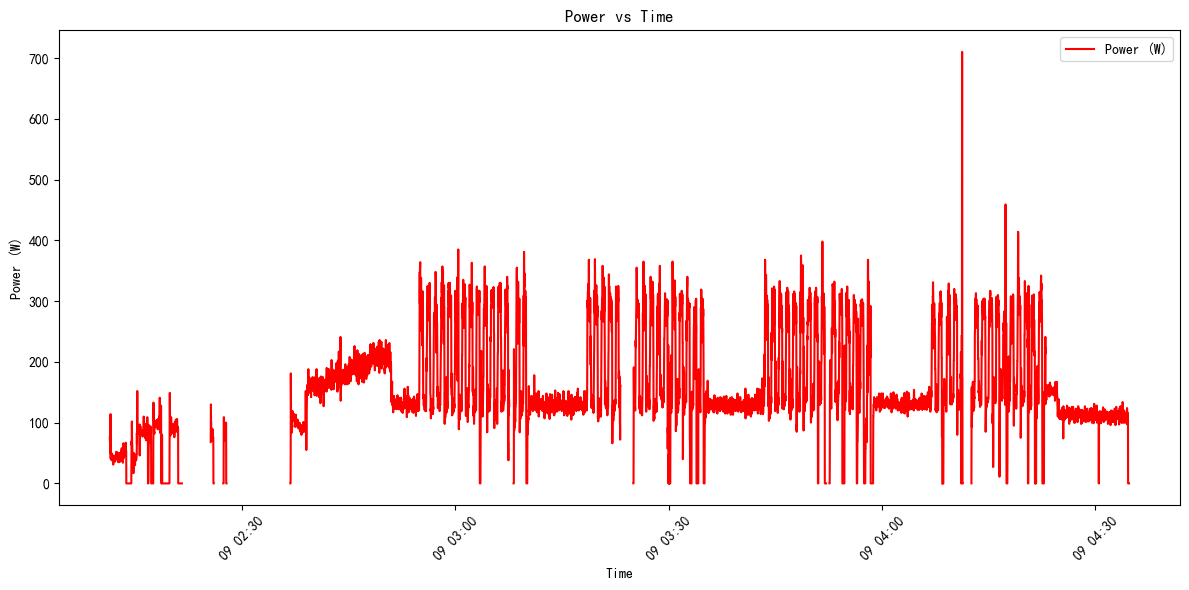


=== Lap 数据 ===
Lap 数量: 134
   message_index          start_time  total_timer_time  total_distance  \
0              0 2026-06-09 02:11:26            608.86         2984.94   
1              1 2026-06-09 02:25:36            180.00         1078.90   
2              2 2026-06-09 02:38:57            180.00         1088.23   
3              3 2026-06-09 02:41:57            180.00         1124.58   
4              4 2026-06-09 02:44:57            180.00         1112.22   

   avg_power  max_power  avg_heart_rate  max_heart_rate  
0         53        152              92             115  
1         87        181              93             118  
2        155        190             117             129  
3        175        241             140             150  
4        192        226             148             153  

=== Session 数据 ===
运动类型: cycling
总时长: 124.6 分钟
总距离: 42.70 km
平均功率: 160 W
最大心率: 181 bpm


In [26]:
import fitparse
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取 FIT 文件
fit_path = './test_data/23182812295_ACTIVITY.fit'

# ========== 1. 提取 record 数据 ==========
fit_file = fitparse.FitFile(fit_path)
records = []
for message in fit_file.get_messages('record'):
    record_dict = {}
    for field in message.fields:
        record_dict[field.name] = field.value
    records.append(record_dict)

df = pd.DataFrame(records)
print(f"=== Record 数据 ===")
print(f"总记录数: {len(df)}")
print(f"时间范围: {df['timestamp'].min()} ~ {df['timestamp'].max()}")
print(f"平均功率: {df['power'].mean():.1f} W")
print(f"平均心率: {df['heart_rate'].mean():.1f} bpm")

# ========== 2. 绘制功率曲线 ==========
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['power'], label='Power (W)', color='red')
plt.xlabel('Time')
plt.ylabel('Power (W)')
plt.title('Power vs Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== 3. 提取 lap 数据（使用正确字段） ==========
fit_file2 = fitparse.FitFile(fit_path)
laps = []
for message in fit_file2.get_messages('lap'):
    lap_dict = {}
    for field in message.fields:
        lap_dict[field.name] = field.value
    laps.append(lap_dict)

lap_df = pd.DataFrame(laps)
print(f"\n=== Lap 数据 ===")
print(f"Lap 数量: {len(lap_df)}")

# 显示关键字段（使用实际存在的字段）
print(lap_df[['message_index', 'start_time', 'total_timer_time', 'total_distance',
              'avg_power', 'max_power', 'avg_heart_rate', 'max_heart_rate']].head())

# ========== 4. 提取 session 数据 ==========
print("\n=== Session 数据 ===")
fit_file3 = fitparse.FitFile(fit_path)
for message in fit_file3.get_messages('session'):
    print(f"运动类型: {message.get('sport').value}")
    print(f"总时长: {message.get('total_timer_time').value / 60:.1f} 分钟")
    print(f"总距离: {message.get('total_distance').value / 1000:.2f} km")
    print(f"平均功率: {message.get('avg_power').value} W")
    print(f"最大心率: {message.get('max_heart_rate').value} bpm")

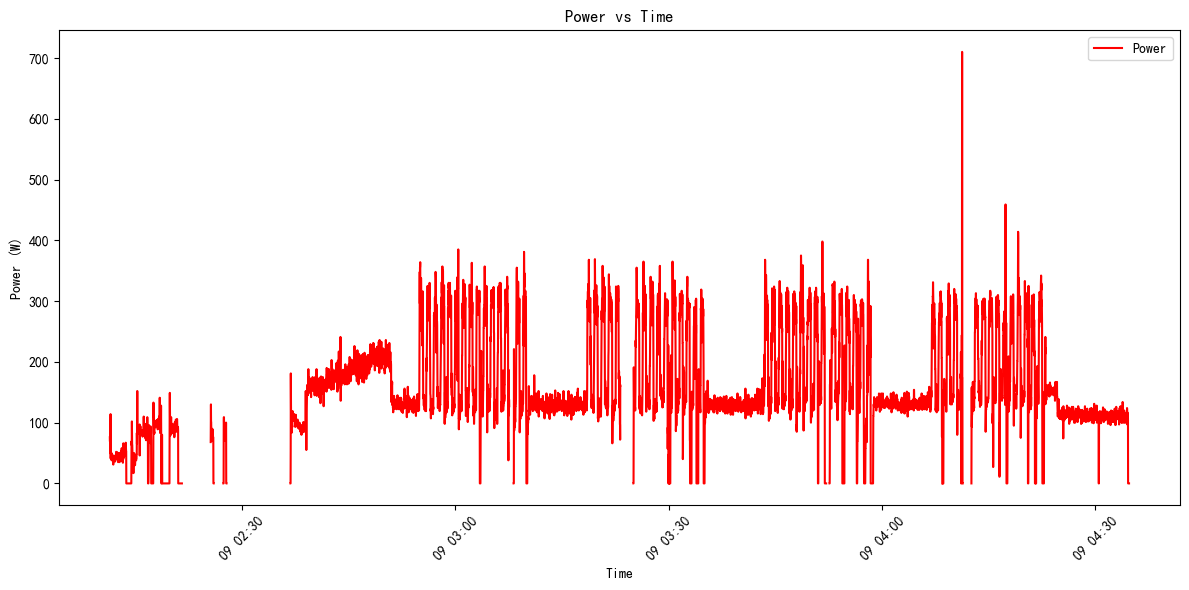

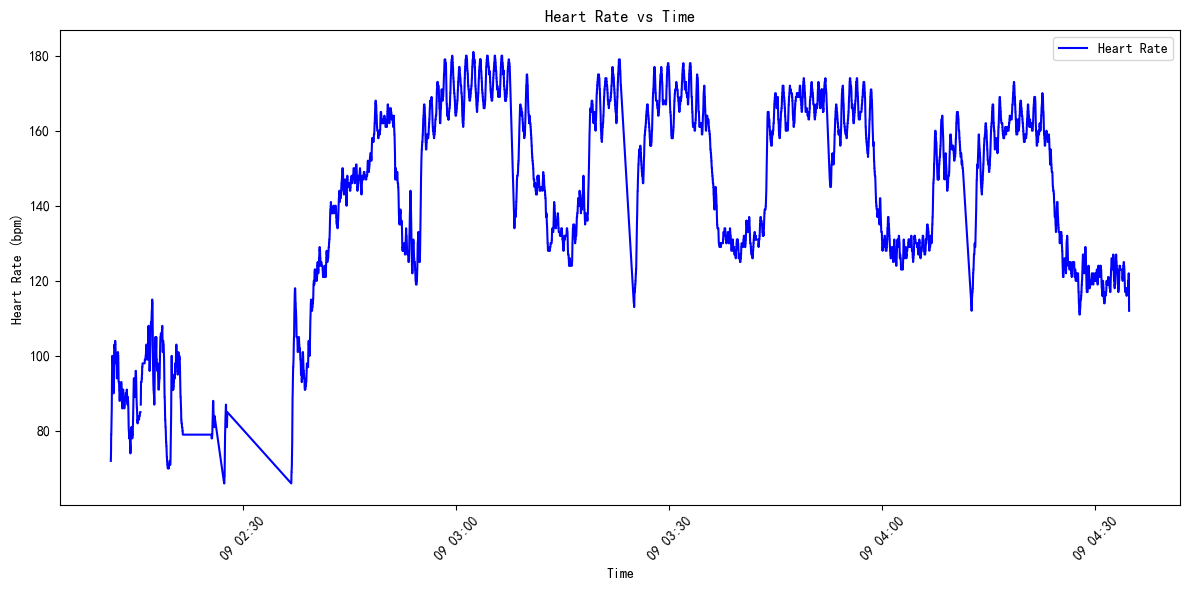

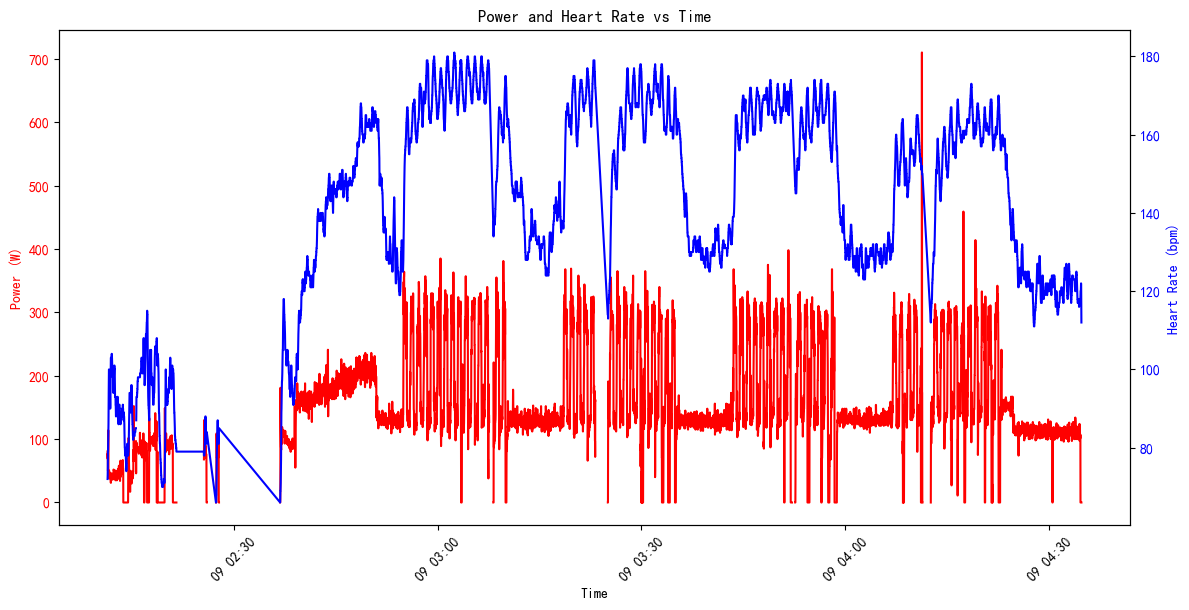

In [27]:
import fitparse
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取 FIT 文件
fit_path = './test_data/23182812295_ACTIVITY.fit'
fit_file = fitparse.FitFile(fit_path)

# 提取 record 数据
records = []
for message in fit_file.get_messages('record'):
    record_dict = {}
    for field in message.fields:
        record_dict[field.name] = field.value
    records.append(record_dict)

df = pd.DataFrame(records)

# ========== 1. 功率曲线 ==========
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['power'], label='Power', color='red')
plt.xlabel('Time')
plt.ylabel('Power (W)')
plt.title('Power vs Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== 2. 心率曲线 ==========
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['heart_rate'], label='Heart Rate', color='blue')
plt.xlabel('Time')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate vs Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== 3. 功率和心率对比图（双Y轴） ==========
fig, ax1 = plt.subplots(figsize=(12, 6))

# 功率曲线（左轴）
ax1.set_xlabel('Time')
ax1.set_ylabel('Power (W)', color='red')
ax1.plot(df['timestamp'], df['power'], color='red', label='Power')
ax1.tick_params(axis='y', labelcolor='red')
plt.xticks(rotation=45)

# 心率曲线（右轴）
ax2 = ax1.twinx()
ax2.set_ylabel('Heart Rate (bpm)', color='blue')
ax2.plot(df['timestamp'], df['heart_rate'], color='blue', label='Heart Rate')
ax2.tick_params(axis='y', labelcolor='blue')

fig.tight_layout()
plt.title('Power and Heart Rate vs Time')
plt.show()